# ⚡ YOLOv8 QUICK TRAINING - Speed Optimized

**Project:** Stock Opname Monitoring  
**Mode:** Fast Training (1-2 hours)  
**Model:** YOLOv8n (Nano - smallest & fastest)  

---

## 🎯 Training Modes Available

| Mode | Time | Accuracy | Use Case |
|------|------|----------|----------|
| **Balanced** | 1-2 jam | 0.45-0.50 | ⭐ Demo/Testing |
| **Super Fast** | 30-45 min | 0.35-0.40 | Quick test |
| **Lightning** | 15-20 min | 0.30-0.35 | Pipeline test only |

**Choose your mode in Configuration section below!**

## 1️⃣ Check GPU

In [1]:
import torch

print("="*70)
print("🖥️  GPU CHECK")
print("="*70)

if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("❌ NO GPU! Go to: Runtime → Change runtime type → GPU")

print("="*70)

🖥️  GPU CHECK
✅ GPU: Tesla T4
   Memory: 15.83 GB


## 2️⃣ Install YOLOv8

In [2]:
!pip install -q ultralytics
from ultralytics import YOLO
print("✅ YOLOv8 installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 33.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ YOLOv8 installed!


## 3️⃣ Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive mounted!")

Mounted at /content/drive
✅ Drive mounted!


## 4️⃣ Setup Paths

In [6]:
import os

PROJECT_DIR = '/content/drive/MyDrive/sku110k'
DATA_DIR = f'{PROJECT_DIR}'
DATA_YAML = f'{DATA_DIR}/data.yaml'
OUTPUT_DIR = f'{PROJECT_DIR}/runs'

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("✅ Paths configured")
print(f"Data: {DATA_DIR}")
print(f"Output: {OUTPUT_DIR}")

✅ Paths configured
Data: /content/drive/MyDrive/sku110k
Output: /content/drive/MyDrive/sku110k/runs


## 5️⃣ Quick Verify Dataset

In [7]:
# Quick check
train_imgs = len(os.listdir(f'{DATA_DIR}/images/train'))
val_imgs = len(os.listdir(f'{DATA_DIR}/images/val'))

print(f"✅ Train images: {train_imgs}")
print(f"✅ Val images: {val_imgs}")
print(f"✅ data.yaml: {'Found' if os.path.exists(DATA_YAML) else 'NOT FOUND'}")

✅ Train images: 6781
✅ Val images: 588
✅ data.yaml: Found


## 6️⃣ Update data.yaml

In [8]:
import yaml

data_config = {
    'path': DATA_DIR,
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'nc': 1,
    'names': ['object']
}

with open(DATA_YAML, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print("✅ data.yaml updated")

✅ data.yaml updated


## ⚙️ 7️⃣ CONFIGURATION - Choose Your Speed!

### **Select ONE option below:**

In [ ]:
# ============================================
# OPTION 1: BALANCED (1-2 JAM) ⭐ RECOMMENDED
# ============================================
"""
TRAINING_MODE = "BALANCED"
MODEL_SIZE = 'yolov8n.pt'     # Nano model (smallest)
EPOCHS = 30                    # Reduced epochs
BATCH_SIZE = 32                # Larger batch for speed
IMG_SIZE = 416                 # Smaller images
FRACTION = 0.5                 # Use 50% of data
CACHE = True                   # Cache for speed

print(f"✅ Mode: {TRAINING_MODE}")
print(f"   Model: {MODEL_SIZE}")
print(f"   Epochs: {EPOCHS}")
print(f"   Data: {int(FRACTION*100)}%")
print(f"   Expected time: 1-2 hours")
print(f"   Expected mAP: 0.45-0.50")
"""

In [ ]:
# ============================================
# OPTION 2: SUPER FAST (30-45 MENIT)
# ============================================
# Uncomment untuk pakai mode ini:

"""
TRAINING_MODE = "SUPER FAST"
MODEL_SIZE = 'yolov8n.pt'
EPOCHS = 10
BATCH_SIZE = 32
IMG_SIZE = 416
FRACTION = 0.3                 # Use 30% of data
CACHE = True

print(f"⚡ Mode: {TRAINING_MODE}")
print(f"   Expected time: 30-45 minutes")
print(f"   Expected mAP: 0.35-0.40")
"""
pass

In [9]:
# ============================================
# OPTION 3: LIGHTNING FAST (15-20 MENIT)
# ============================================
# Uncomment untuk pakai mode ini:

TRAINING_MODE = "LIGHTNING"
MODEL_SIZE = 'yolov8n.pt'
EPOCHS = 5
BATCH_SIZE = 32
IMG_SIZE = 320                 # Very small
FRACTION = 0.2                 # Use 20% of data
CACHE = True

print(f"🚀 Mode: {TRAINING_MODE}")
print(f"   Expected time: 15-20 minutes")
print(f"   Expected mAP: 0.30-0.35")
print(f"   ⚠️  LOW ACCURACY - Testing only!")

🚀 Mode: LIGHTNING
   Expected time: 15-20 minutes
   Expected mAP: 0.30-0.35
   ⚠️  LOW ACCURACY - Testing only!


## 8️⃣ Training Args

In [10]:
train_args = {
    'data': DATA_YAML,
    'epochs': EPOCHS,
    'batch': BATCH_SIZE,
    'imgsz': IMG_SIZE,
    'device': 0,
    'cache': CACHE,
    'fraction': FRACTION,      # Use only subset of data
    'patience': 10,             # Early stopping (reduced)
    'save': True,
    'save_period': -1,          # Don't save intermediate (faster)
    'project': OUTPUT_DIR,
    'name': f'quick_training_{TRAINING_MODE.lower().replace(" ", "_")}',
    'exist_ok': True,
    'pretrained': True,
    'optimizer': 'Adam',        # Adam faster than SGD
    'verbose': True,
    'single_cls': True,
    'amp': True,                # Mixed precision for speed
    'workers': 8,
}

print("="*70)
print("⚙️  TRAINING CONFIGURATION")
print("="*70)
for key, value in train_args.items():
    print(f"  {key:20s}: {value}")
print("="*70)

⚙️  TRAINING CONFIGURATION
  data                : /content/drive/MyDrive/sku110k/data.yaml
  epochs              : 5
  batch               : 32
  imgsz               : 320
  device              : 0
  cache               : True
  fraction            : 0.2
  patience            : 10
  save                : True
  save_period         : -1
  project             : /content/drive/MyDrive/sku110k/runs
  name                : quick_training_lightning
  exist_ok            : True
  pretrained          : True
  optimizer           : Adam
  verbose             : True
  single_cls          : True
  amp                 : True
  workers             : 8


## 🚀 9️⃣ START TRAINING!

In [11]:
from datetime import datetime

print("="*70)
print(f"🚀 STARTING {TRAINING_MODE} TRAINING")
print("="*70)
print(f"Start: {datetime.now().strftime('%H:%M:%S')}")
print(f"Mode: {TRAINING_MODE}")
print(f"Model: {MODEL_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Data: {int(FRACTION*100)}%")
print("\n⏰ Estimated time:")
if TRAINING_MODE == "BALANCED":
    print("   1-2 hours")
elif TRAINING_MODE == "SUPER FAST":
    print("   30-45 minutes")
else:
    print("   15-20 minutes")
print("\n" + "="*70 + "\n")

# Load model
model = YOLO(MODEL_SIZE)

# Start training
start_time = datetime.now()
results = model.train(**train_args)
end_time = datetime.now()

duration = (end_time - start_time).total_seconds() / 60

print("\n" + "="*70)
print("✅ TRAINING COMPLETE!")
print(f"Duration: {duration:.1f} minutes ({duration/60:.2f} hours)")
print("="*70)

🚀 STARTING LIGHTNING TRAINING
Start: 12:53:26
Mode: LIGHTNING
Model: yolov8n.pt
Epochs: 5
Data: 20%

⏰ Estimated time:
   15-20 minutes


Ultralytics 8.3.221 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/sku110k/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=0.2, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False,

## 🔟 Quick Validation

In [12]:
# Load best model
run_name = f'quick_training_{TRAINING_MODE.lower().replace(" ", "_")}'
best_model_path = f"{OUTPUT_DIR}/{run_name}/weights/best.pt"
best_model = YOLO(best_model_path)

print(f"✅ Loaded: {best_model_path}")

# Quick validation
print("\n🔍 Running validation...\n")
metrics = best_model.val(data=DATA_YAML, split='val')

# Results
print("\n" + "="*70)
print(f"📊 {TRAINING_MODE} MODE RESULTS")
print("="*70)
print(f"\nmAP@0.5:      {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95: {metrics.box.map:.4f}")
print(f"Precision:    {metrics.box.mp:.4f}")
print(f"Recall:       {metrics.box.mr:.4f}")
print("\n" + "="*70)

# Benchmark comparison
if metrics.box.map50 >= 0.50:
    print("✅ EXCELLENT! mAP > 0.50 - Production ready!")
elif metrics.box.map50 >= 0.40:
    print("✅ GOOD! mAP > 0.40 - Good for demo/testing!")
elif metrics.box.map50 >= 0.30:
    print("⚠️  OK - mAP > 0.30 - Pipeline works, but low accuracy")
else:
    print("❌ LOW - Consider training longer or with more data")

print("="*70)

✅ Loaded: /content/drive/MyDrive/sku110k/runs/quick_training_lightning/weights/best.pt

🔍 Running validation...

Ultralytics 8.3.221 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.0 ms, read: 356.0±136.0 MB/s, size: 1655.4 KB)
val: Scanning /content/drive/MyDrive/sku110k/labels/val.cache... 588 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 588/588 832.1Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 37/37 0.9it/s 42.7s
                   all        588      90968      0.655      0.544      0.604      0.283
Speed: 0.7ms preprocess, 4.2ms inference, 0.0ms loss, 5.7ms postprocess per image
Results saved to /content/runs/detect/val

📊 LIGHTNING MODE RESULTS

mAP@0.5:      0.6037
mAP@0.5:0.95: 0.2828
Precision:    0.6550
Recall:       0.5445

✅ EXCELLENT! mAP > 0.50 - Production read

## 1️⃣1️⃣ View Results

📊 Training Results:

Training Curves:


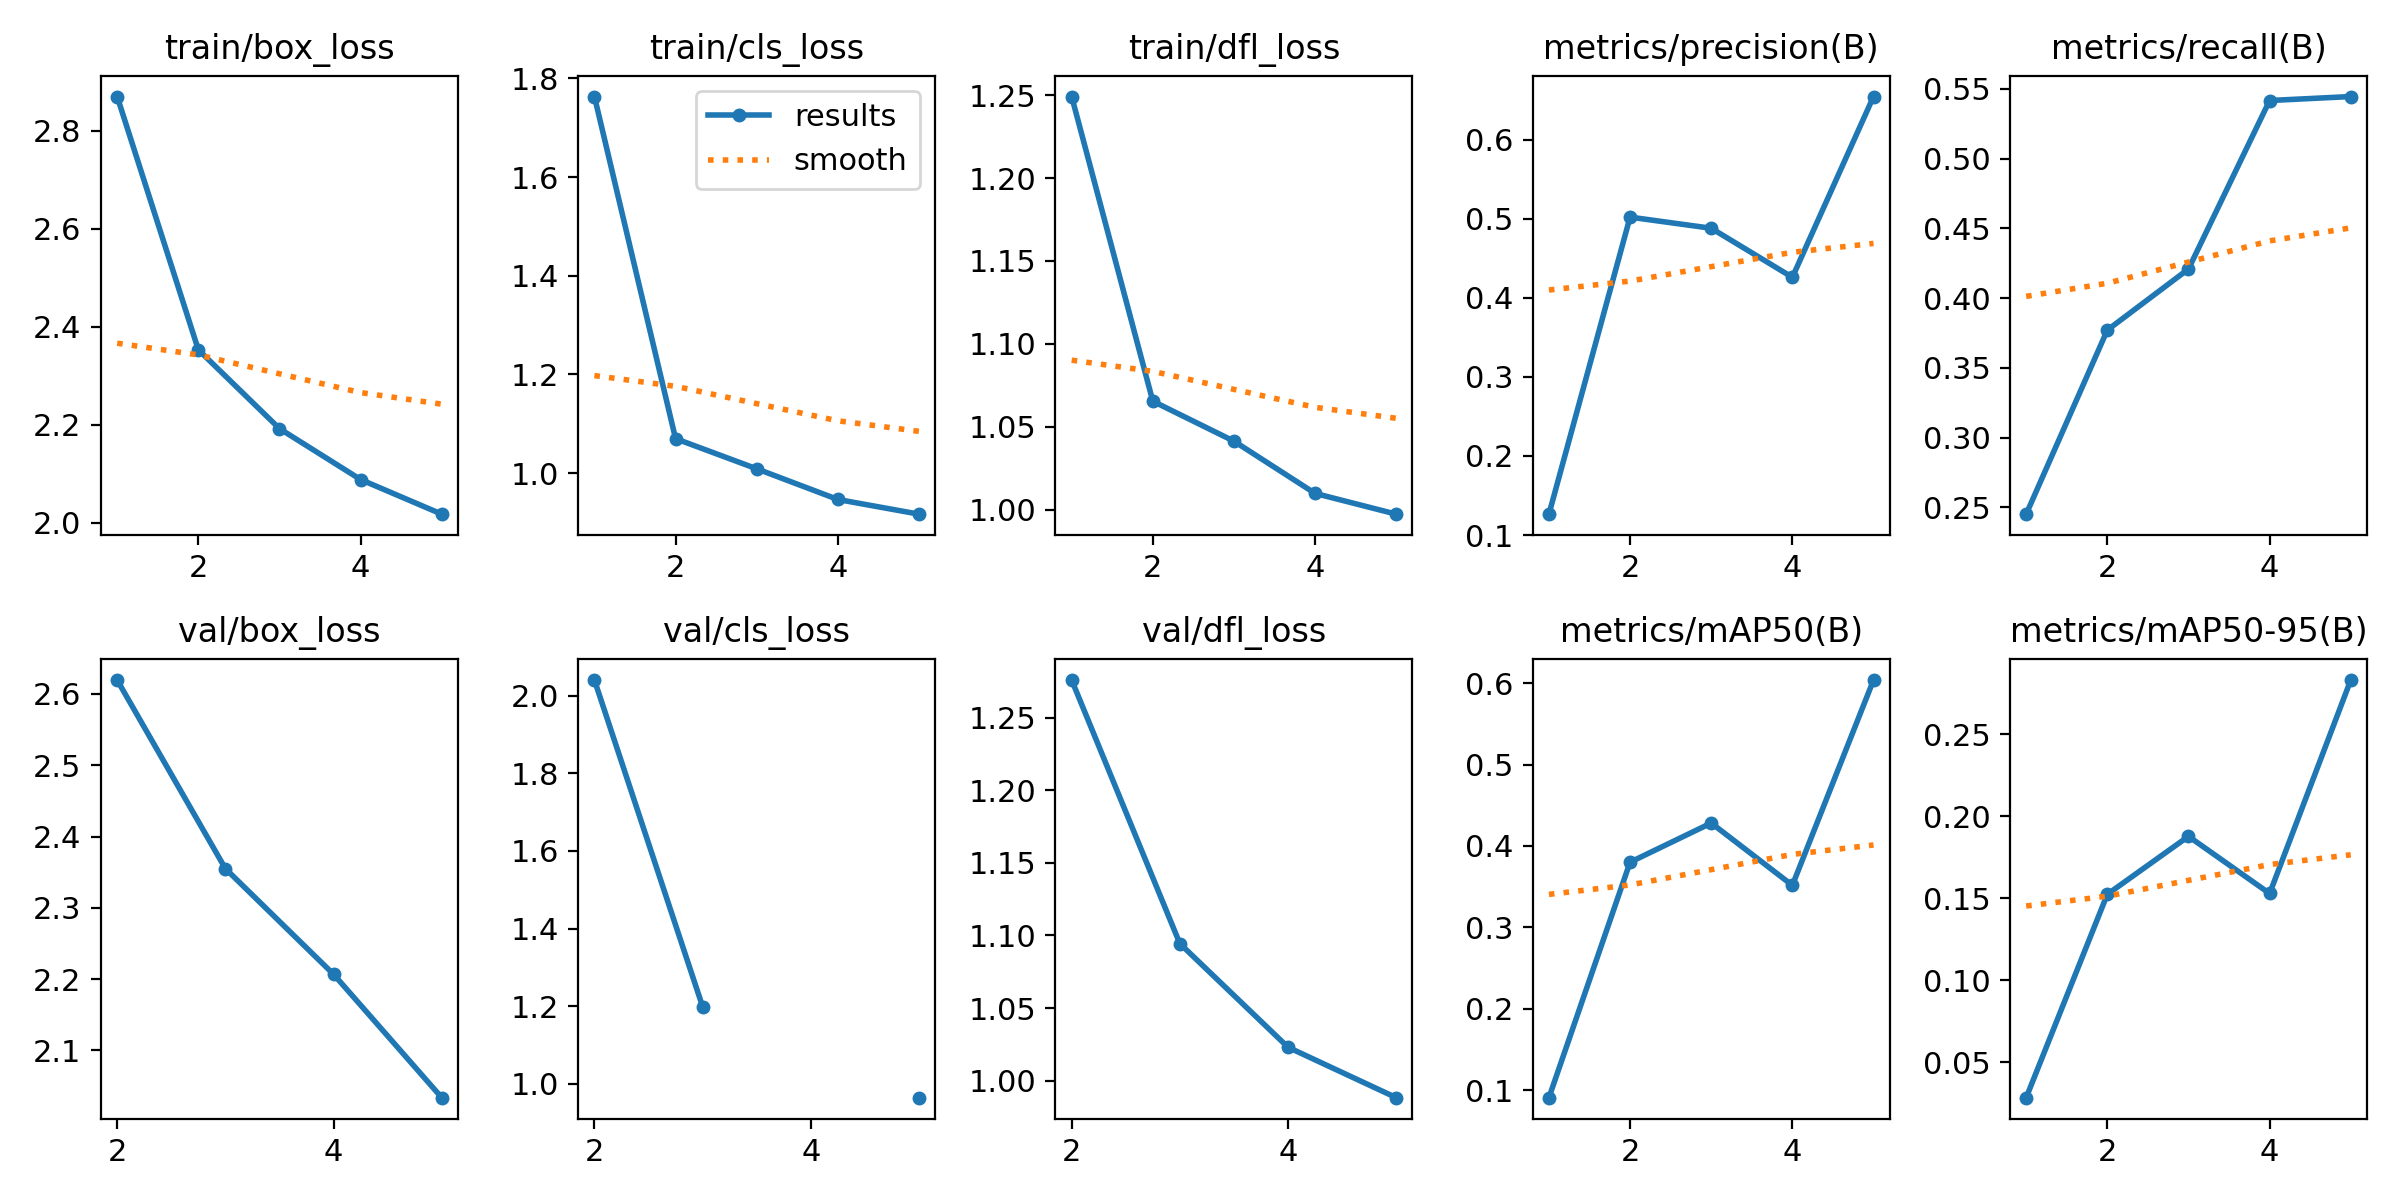


Confusion Matrix:


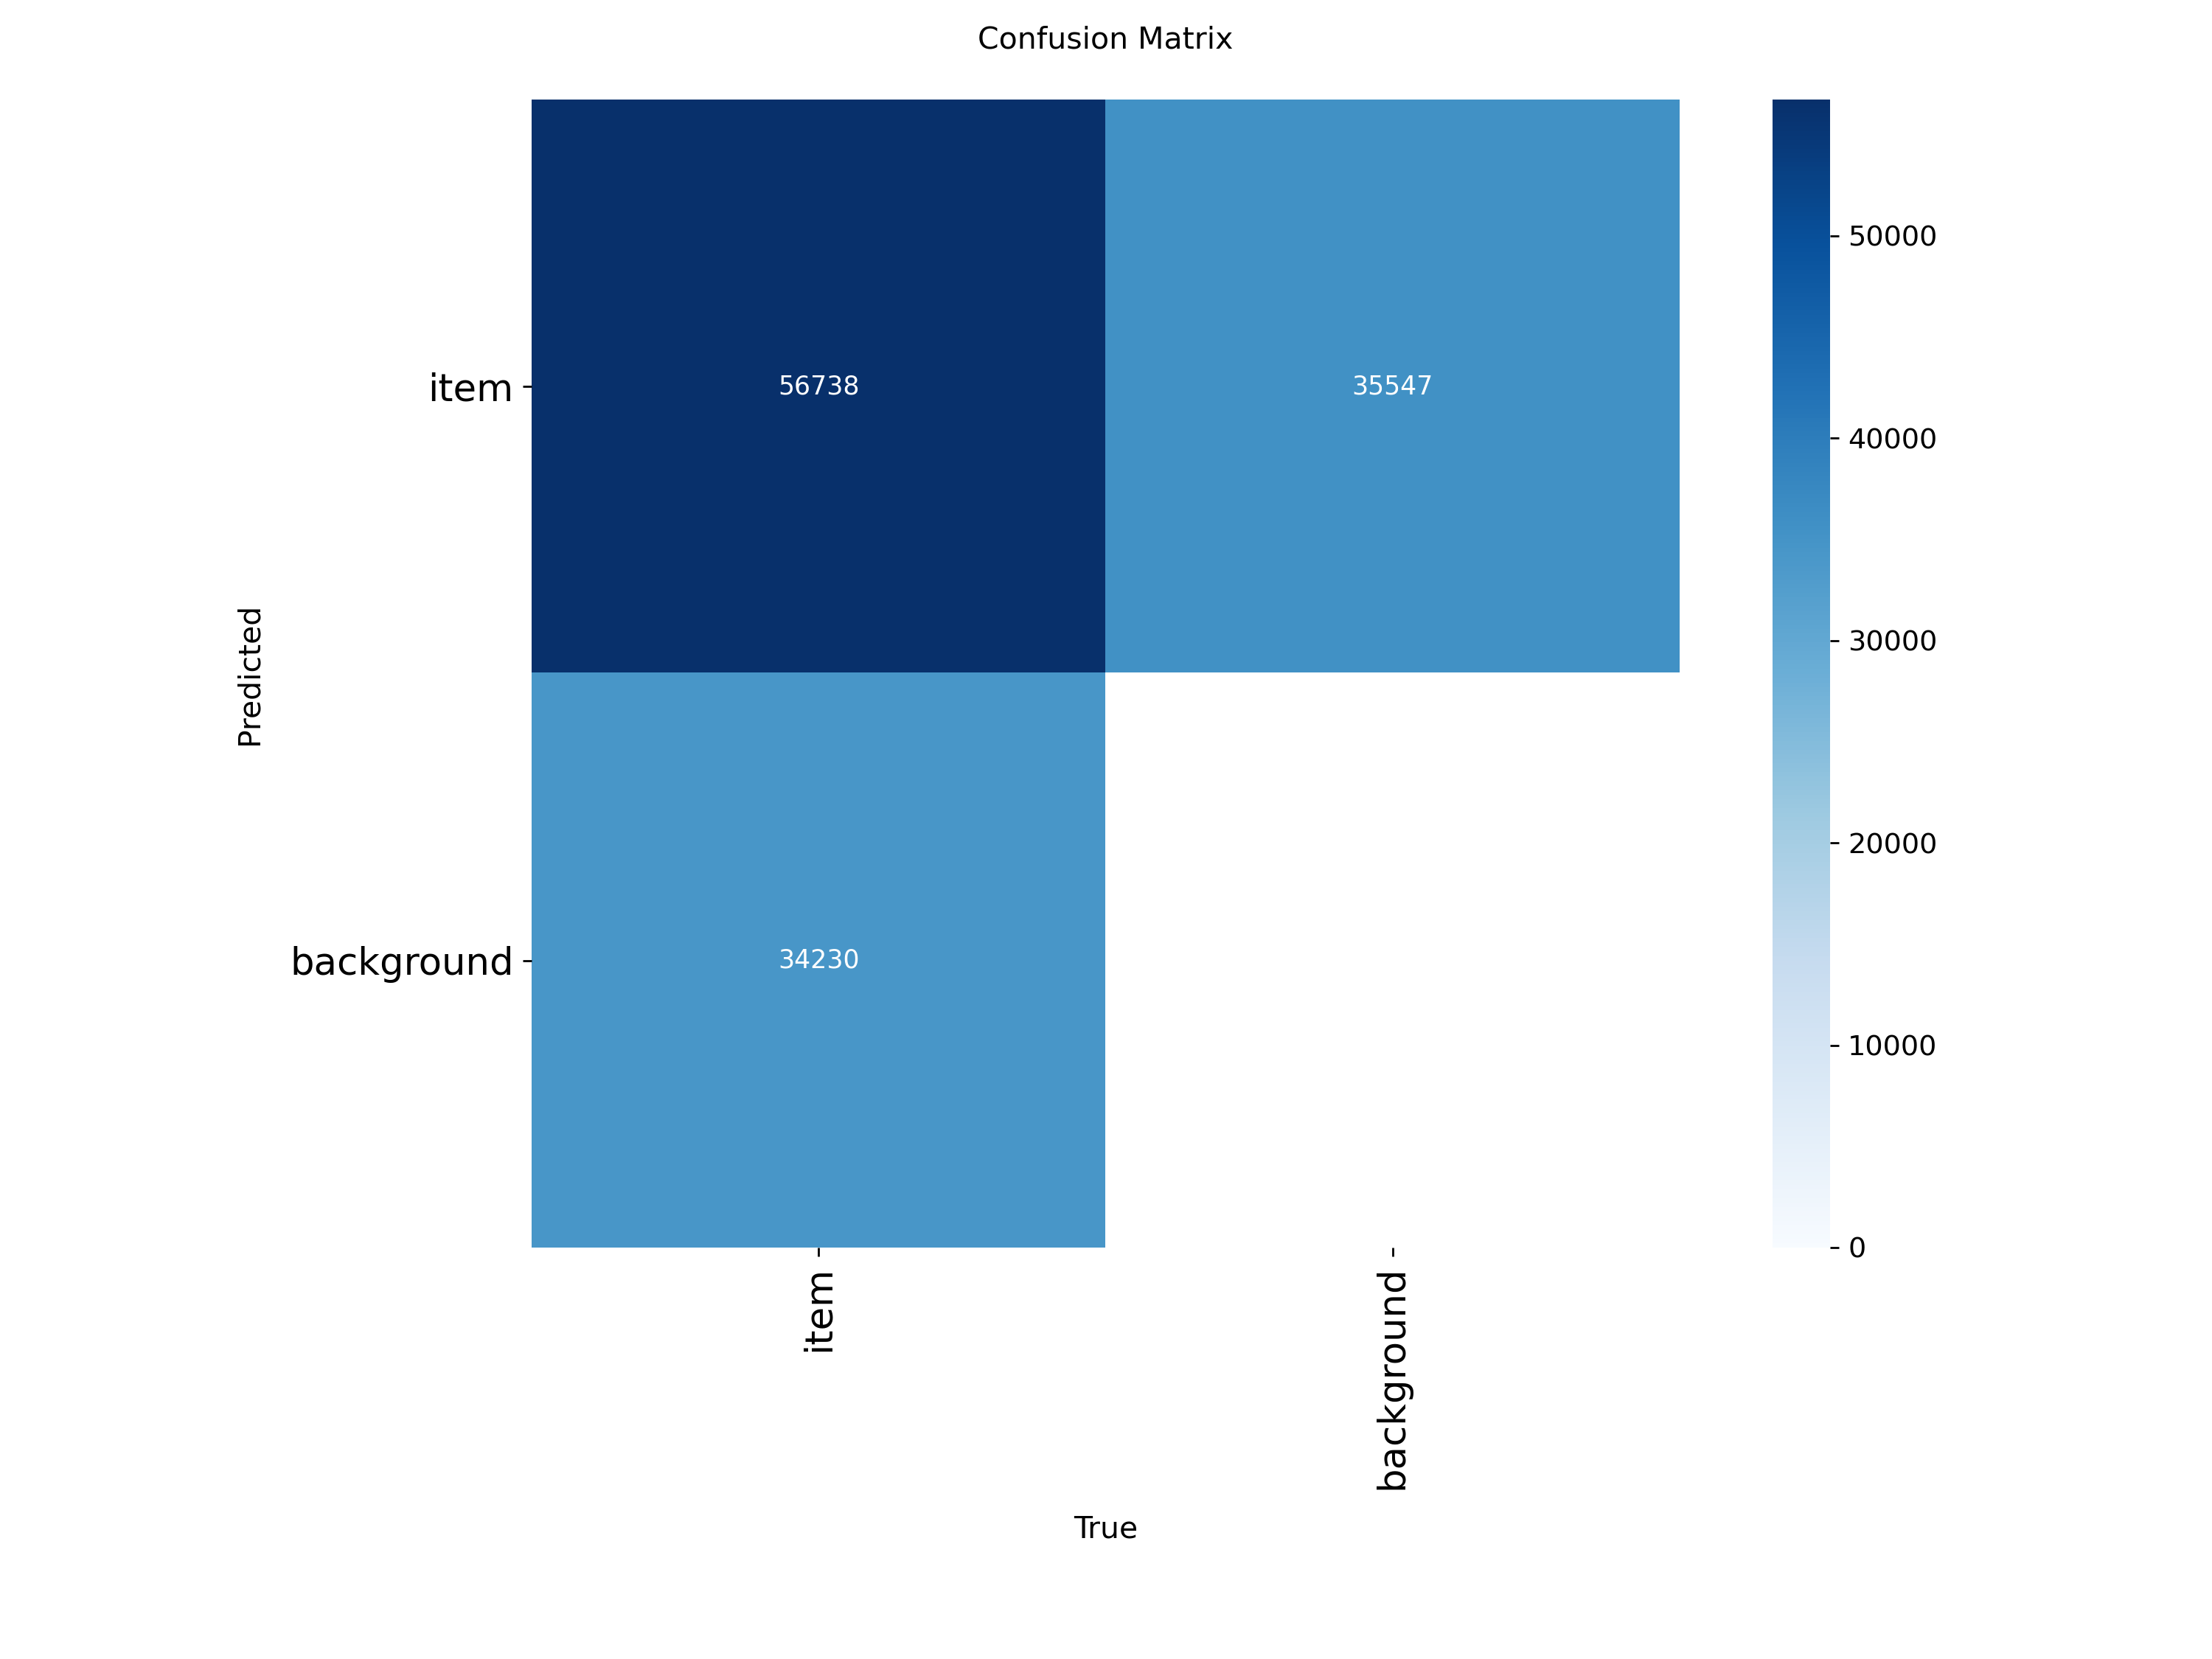

In [13]:
from IPython.display import Image, display

results_dir = f"{OUTPUT_DIR}/{run_name}"

print("📊 Training Results:\n")

# Results curve
if os.path.exists(f"{results_dir}/results.png"):
    print("Training Curves:")
    display(Image(filename=f"{results_dir}/results.png", width=800))

# Confusion matrix
if os.path.exists(f"{results_dir}/confusion_matrix.png"):
    print("\nConfusion Matrix:")
    display(Image(filename=f"{results_dir}/confusion_matrix.png", width=600))

## 1️⃣2️⃣ Test Inference

🔍 Testing on: val_53.jpg


image 1/1 /content/drive/MyDrive/sku110k/images/val/val_53.jpg: 320x256 241 items, 69.5ms
Speed: 1.4ms preprocess, 69.5ms inference, 2.6ms postprocess per image at shape (1, 3, 320, 256)


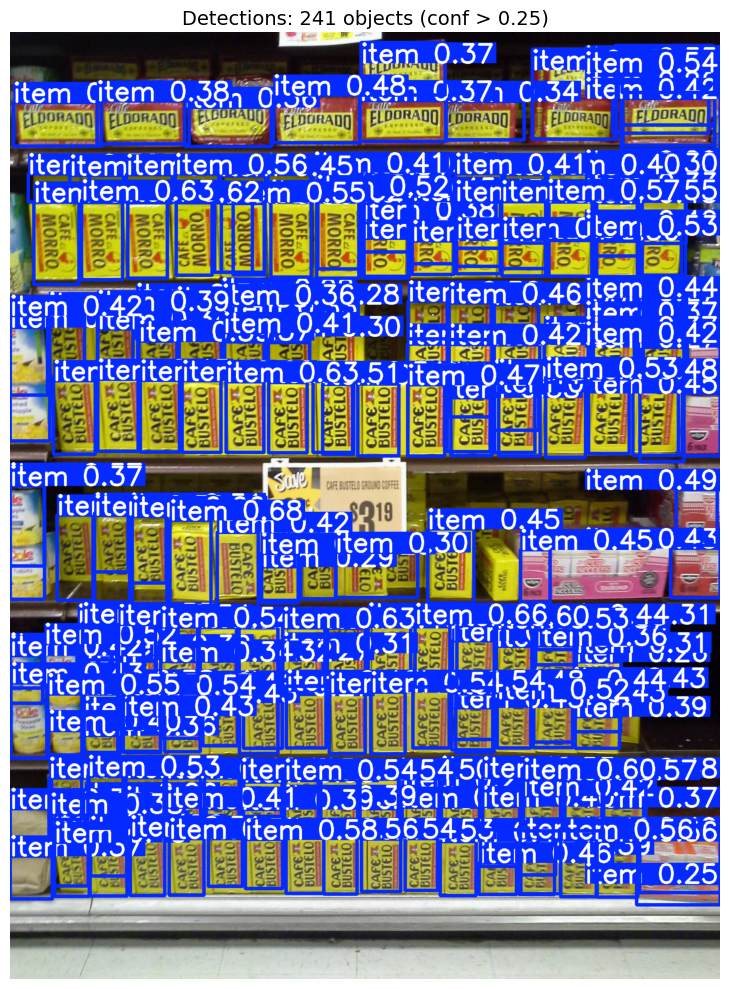


✅ Detected 241 objects


In [14]:
import matplotlib.pyplot as plt
import cv2

# Get sample image
val_images_dir = f"{DATA_DIR}/images/val"
sample_img = os.path.join(val_images_dir, os.listdir(val_images_dir)[0])

print(f"🔍 Testing on: {os.path.basename(sample_img)}\n")

# Run inference
results = best_model.predict(source=sample_img, conf=0.25, save=False)

# Display
annotated = results[0].plot()
annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15, 10))
plt.imshow(annotated_rgb)
plt.axis('off')
plt.title(f'Detections: {len(results[0].boxes)} objects (conf > 0.25)', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\n✅ Detected {len(results[0].boxes)} objects")

## 1️⃣3️⃣ Download Model

In [15]:
from google.colab import files

print(f"📦 Downloading trained model...")
print(f"File: {best_model_path}")
print(f"Size: {os.path.getsize(best_model_path) / 1e6:.1f} MB\n")

files.download(best_model_path)

print("\n✅ Download started!")
print(f"\nModel also saved in Drive: {best_model_path}")

📦 Downloading trained model...
File: /content/drive/MyDrive/sku110k/runs/quick_training_lightning/weights/best.pt
Size: 6.2 MB



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Download started!

Model also saved in Drive: /content/drive/MyDrive/sku110k/runs/quick_training_lightning/weights/best.pt


## 🎉 Quick Training Complete!

### Summary:
```
✅ Training mode: [YOUR MODE]
✅ Duration: [TIME] minutes
✅ mAP@0.5: [SCORE]
✅ Model saved in Google Drive
```

### Trade-offs:
- ⚡ **FASTER** training (1-2 hours vs 20+ hours)
- ⚠️  **LOWER** accuracy (0.45 vs 0.60 mAP)
- ✅ **GOOD** for: Demo, testing, proof of concept
- ❌ **NOT** for: Production deployment

### To Improve Accuracy:
1. Use more data (fraction=1.0)
2. Train longer (epochs=100)
3. Use larger model (yolov8s or yolov8m)

### Next Steps:
- Test model on your own images
- If accuracy good enough → proceed to deployment
- If need better → train longer with full data